In [5]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df_pred = pd.read_csv("dirty_v3_path.csv")
df_risk = pd.read_csv("healthcare_prediction_dataset.csv")

In [9]:
print(df_pred.head())
# print(df_risk.head())

    Age  Gender Medical Condition  Glucose  Blood Pressure    BMI  \
0  46.0    Male          Diabetes   137.04          135.27  28.90   
1  22.0    Male           Healthy    71.58          113.27  26.29   
2  50.0     NaN            Asthma    95.24             NaN  22.53   
3  57.0     NaN           Obesity      NaN          130.53  38.47   
4  66.0  Female      Hypertension    95.15          178.17  31.12   

   Oxygen Saturation  LengthOfStay  Cholesterol  Triglycerides  HbA1c  \
0              96.04             6       231.88         210.56   7.61   
1              97.54             2       165.57         129.41   4.91   
2              90.31             2       214.94         165.35   5.60   
3              96.60             5       197.71         182.13   6.92   
4              94.90             4       259.53         115.85   5.98   

   Smoking  Alcohol  Physical Activity  Diet Score  Family History  \
0        0        0              -0.20        3.54               0   
1     

In [11]:
print(df_pred.isna().sum())
print(df_risk.isna().sum())

Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [13]:
for col in df_pred.select_dtypes(include=["float64","int64"]):
    df_pred[col].fillna(df_pred[col].median(), inplace=True)
    
for col in df_risk.select_dtypes(include=["float64","int64"]):
    df_risk[col].fillna(df_risk[col].median(), inplace=True)

In [15]:
for col in df_pred.select_dtypes(include=["object"]):
    df_pred[col].fillna(df_pred[col].mode()[0], inplace=True)
    
for col in df_risk.select_dtypes(include=["object"]):
    df_risk[col].fillna(df_risk[col].mode()[0], inplace=True)

In [17]:
from sklearn.preprocessing import OneHotEncoder

df_pred = pd.get_dummies(df_pred, drop_first=True)
df_risk = pd.get_dummies(df_risk, drop_first=True)

In [19]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# num_cols_pred = df_pred.select_dtypes(include=["float64","int64"]).columns
# num_cols_risk = df_risk.select_dtypes(include=["float64","int64"]).columns

# df_pred[num_cols_pred] = scaler.fit_transform(df_pred[num_cols_pred])
# df_risk[num_cols_risk] = scaler.fit_transform(df_risk[num_cols_risk])

In [21]:
# Descriptive stats

In [23]:
df_pred['HbA1c'].describe()

count    30000.000000
mean         6.294377
std          1.320269
min          3.280000
25%          5.330000
50%          5.970000
75%          6.920000
max         12.360000
Name: HbA1c, dtype: float64

In [25]:
df_pred['HighRisk'] = (df_pred['HbA1c'] > 0).astype(int)
df_pred['HighRisk'].value_counts()

HighRisk
1    30000
Name: count, dtype: int64

In [27]:
from scipy.stats import ttest_ind

low = df_pred[df_pred['HighRisk'] == 0]['BMI']
high = df_pred[df_pred['HighRisk'] == 1]['BMI']

t, p = ttest_ind(low, high, equal_var=False)

print("T-stat:", t)
print("p-value:", p)

low = df_pred[df_pred['HighRisk'] == 0]['Glucose']
high = df_pred[df_pred['HighRisk'] == 1]['Glucose']

t, p = ttest_ind(low, high, equal_var=False)

print("Glucose T-stat:", t)
print("Glucose p-value:", p)

low = df_pred[df_pred['HighRisk'] == 0]['Cholesterol']
high = df_pred[df_pred['HighRisk'] == 1]['Cholesterol']

t, p = ttest_ind(low, high, equal_var=False)

print("Cholesterol T-stat:", t)
print("Cholesterol p-value:", p)

low = df_pred[df_pred['HighRisk'] == 0]['Blood Pressure']
high = df_pred[df_pred['HighRisk'] == 1]['Blood Pressure']

t, p = ttest_ind(low, high, equal_var=False)

print("Blood Pressure T-stat:", t)
print("Blood Pressure p-value:", p)

T-stat: nan
p-value: nan
Glucose T-stat: nan
Glucose p-value: nan
Cholesterol T-stat: nan
Cholesterol p-value: nan
Blood Pressure T-stat: nan
Blood Pressure p-value: nan


In [29]:
from scipy.stats import pearsonr

variables = ['BMI', 'Glucose', 'Cholesterol', 'Blood Pressure']

for var in variables:
    r, p = pearsonr(df_pred[var], df_pred['HbA1c'])
    print(f"{var}: r = {r:.3f}, p = {p:.4e}")

BMI: r = 0.125, p = 1.7298e-105
Glucose: r = 0.562, p = 0.0000e+00
Cholesterol: r = 0.026, p = 9.0295e-06
Blood Pressure: r = 0.044, p = 4.4911e-14


In [31]:
#prelimary test r BMI
#separate test for BMI and HbA1c
# from scipy.stats import pearsonr, ttest_ind
# r, p = pearsonr(df_pred['BMI'], df_pred['HbA1c'])
# print("Correlation:", r, "p-value:", p)

# # t-test
# group1 = df_pred[df_pred['Smoking'] == 1]['HbA1c']
# group0 = df_pred[df_pred['Smoking'] == 0]['HbA1c']
# t, p = ttest_ind(group1, group0)
# print("T-test:", t, "p-value:", p)


In [33]:
import statsmodels.api as sm

X = df_pred[['BMI', 'Glucose', 'Cholesterol', 'Blood Pressure']]
X = sm.add_constant(X)

y = df_pred['HbA1c']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  HbA1c   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     3593.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:22:02   Log-Likelihood:                -45031.
No. Observations:               30000   AIC:                         9.007e+04
Df Residuals:                   29995   BIC:                         9.011e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.2402      0.062     52.

In [35]:
#this may indicate that there is no positive correlation, weak correlation; statistically significant values 

# Linear Regression Modeling

In [38]:
X = df_pred[['BMI', 'Glucose', 'Cholesterol', 'Blood Pressure']]
y = df_pred['HbA1c']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [46]:
y_pred = linear_model.predict(X_test_scaled)

In [48]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R-Squared: ", r2)
print("MSE: ", rmse)
print("MAE: ", mae)

R-Squared:  0.31951422927567996
MSE:  1.088852888325087
MAE:  0.8228353416396776


In [50]:
#model coefficients

coefficients = pd.DataFrame({"feature: ": X.columns, "coefficients: ": linear_model.coef_})

print(coefficients)

        feature:   coefficients: 
0             BMI        0.111338
1         Glucose        0.735018
2     Cholesterol        0.012500
3  Blood Pressure        0.012225


In [ ]:
#actual vs predicted visualisation

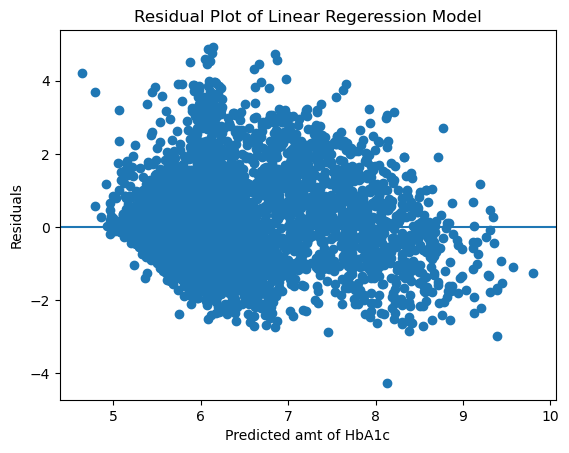

In [52]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted amt of HbA1c")
plt.ylabel("Residuals")
plt.title("Residual Plot of Linear Regeression Model")
plt.show()

# Random Forest Model

In [55]:
from sklearn.ensemble import RandomForestRegressor

rand_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = None,
    random_state = 42,
    n_jobs = -1)

rand_model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [57]:
rf_pred = rand_model.predict(X_test)

In [61]:
#RF model eval
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)

print("Random Forest R-Squared: ", r2_rf)
print("Random Forest MSE: ", rmse_rf)
print("Random Forest MAE: ", mae_rf)

Random Forest R-Squared:  0.34952012746396055
Random Forest MSE:  1.0645758619022883
Random Forest MAE:  0.80245645


In [63]:
# wanted to see if RF can do feature imporance for clinical variables

In [71]:
importance = pd.DataFrame({"Feature": X.columns, "Importance": rand_model.feature_importances_})

importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

          Feature  Importance
1         Glucose    0.488091
2     Cholesterol    0.175992
0             BMI    0.170609
3  Blood Pressure    0.165309


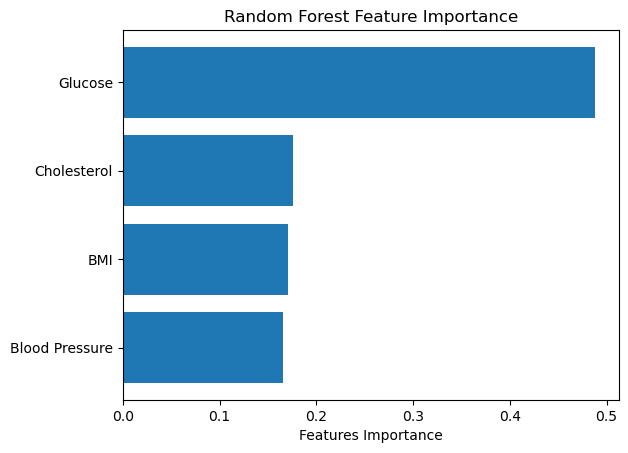

In [75]:
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Features Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()